# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [4]:
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [5]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [6]:
# Não há dados faltantes e a classificação das colunas está correta.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [7]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [8]:
# A quantidade maxima está muito acima das porcentagens inferiores, indicando a presença de outliers.

In [9]:
colunas_outliers = ['Valor_Aluguel', 'Valor_Condominio', 'Metragem',
                    'N_Quartos', 'N_banheiros', 'N_Suites']

df_clean = df.copy()

for col in colunas_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 -1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= limite_inferior) & (df_clean[col] <= limite_superior)]

print(f"Linhas originais: {len(df)} | Linhas pós-tratamento: {len(df_clean)}")

Linhas originais: 7203 | Linhas pós-tratamento: 5573


In [10]:
df_clean.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000
mean,1905.268796,516.699803,63.275076,2.063341,1.742150,0.714158,1.136551
std,910.704464,299.508279,18.810983,0.670719,0.508095,0.481468,0.479868
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000
25%,1250.000000,350.000000,50.000000,2.000000,1.000000,0.000000,1.000000
50%,1600.000000,500.000000,60.000000,2.000000,2.000000,1.000000,1.000000
75%,2400.000000,694.000000,73.000000,3.000000,2.000000,1.000000,1.000000
max,5900.000000,1440.000000,120.000000,4.000000,3.000000,2.000000,3.000000


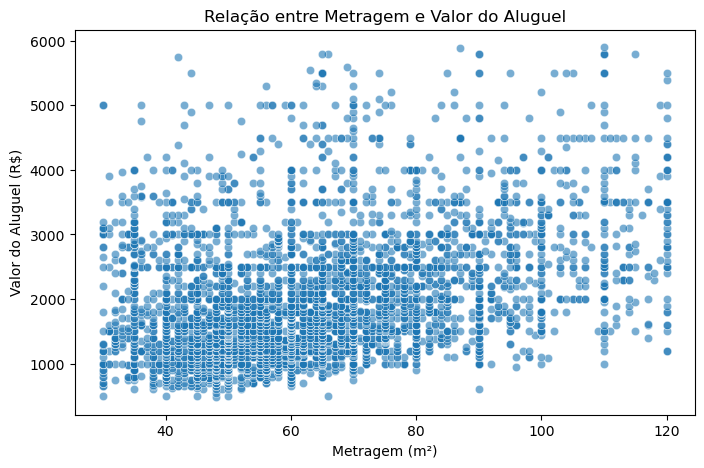

In [11]:
# Metragem vs. Valor do Aluguel
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Metragem', y='Valor_Aluguel', alpha=0.6)
plt.title('Relação entre Metragem e Valor do Aluguel')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel (R$)')
plt.show()

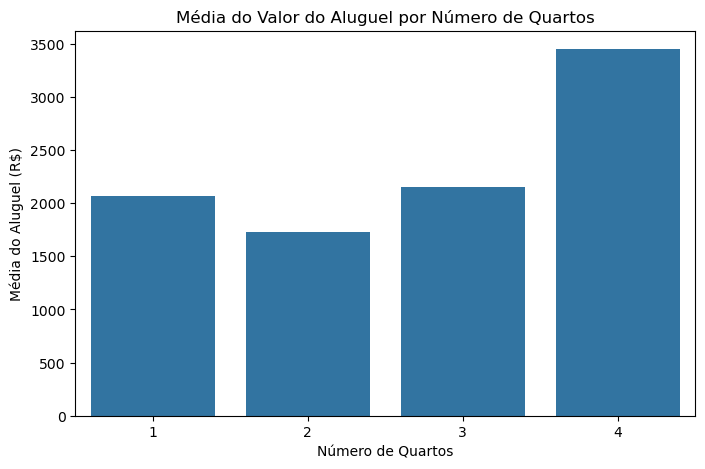

In [12]:
# Número de Quartos vs. Média do Aluguel
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='N_Quartos', y='Valor_Aluguel', errorbar=None)
plt.title('Média do Valor do Aluguel por Número de Quartos')
plt.xlabel('Número de Quartos')
plt.ylabel('Média do Aluguel (R$)')
plt.show()

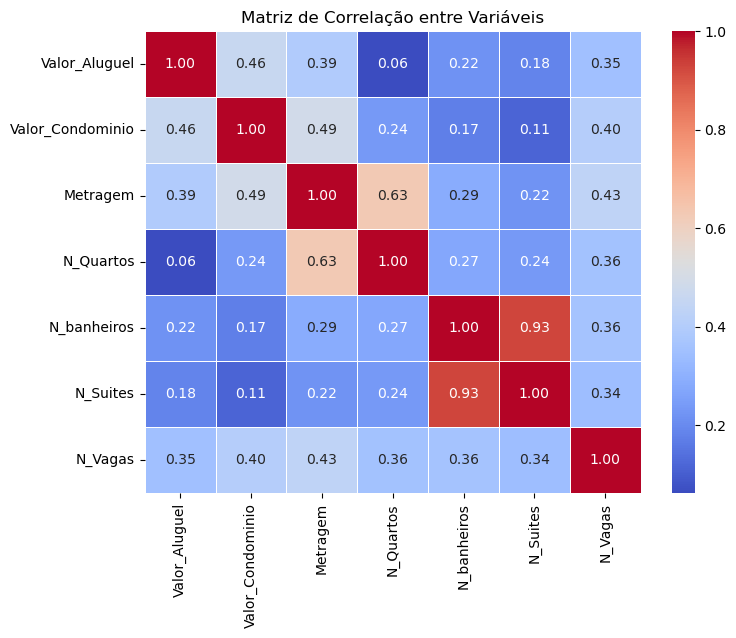

In [13]:
# Matriz de Correlação Geral
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

In [14]:
print(df_clean['N_Vagas'].value_counts())
print("Desvio Padrão:", df_clean['N_Vagas'].std())

N_Vagas
1    4297
2     963
0     276
3      37
Name: count, dtype: int64
Desvio Padrão: 0.4798683181542055


# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




<Axes: xlabel='Valor_Condominio', ylabel='Valor_Aluguel'>

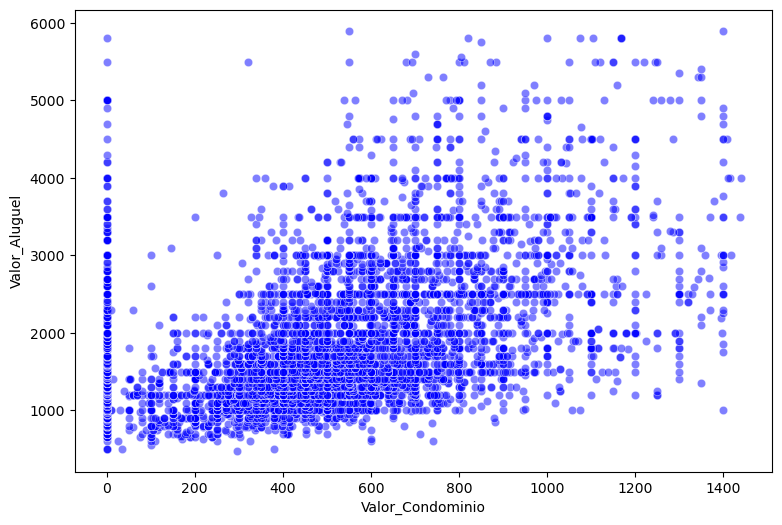

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean, 
    x='Valor_Condominio', 
    y='Valor_Aluguel', 
    alpha=0.5, 
    color='b'
)


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [19]:
X = df_clean.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df_clean['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino X: {X_train.shape} | Teste X: {X_test.shape}")
print(f"Treino y: {y_train.shape} | Teste y: {y_test.shape}")

Treino X: (4458, 6) | Teste X: (1115, 6)
Treino y: (4458,) | Teste y: (1115,)


Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [ ]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [20]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.

X_train_simple = X_train[['Metragem']]
y_train_simple = y_train

modelo_simples = LinearRegression()
modelo_simples.fit(X_train_simple, y_train_simple)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [21]:
intercepto = modelo_simples.intercept_
coeficiente = modelo_simples.coef_[0]

print(f"Intercepto (a): {intercepto:.2f}")
print(f"Coeficiente (b): {coeficiente:.2f}")
print(f"\nEquação da Reta: Valor_Aluguel = {intercepto:.2f} + ({coeficiente:.2f} * Metragem)")

Intercepto (a): 729.13
Coeficiente (b): 18.69

Equação da Reta: Valor_Aluguel = 729.13 + (18.69 * Metragem)


c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [22]:
r2_treino = modelo_simples.score(X_train_simple, y_train_simple)
print(f"R² nos dados de Treino: {r2_treino:.4f}")

R² nos dados de Treino: 0.1477


D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

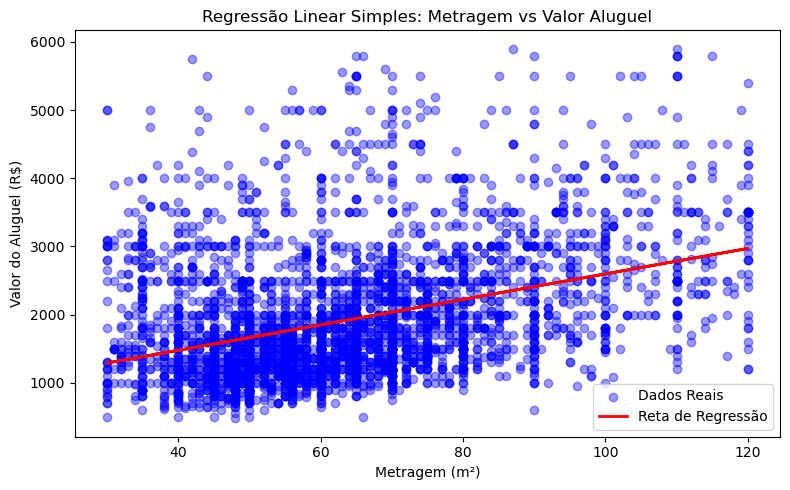

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train_simple, y_train_simple, alpha=0.4, color='blue', label='Dados Reais')
plt.plot(X_train_simple, modelo_simples.predict(X_train_simple), color='red', linewidth=2, label='Reta de Regressão')

plt.title('Regressão Linear Simples: Metragem vs Valor Aluguel')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel (R$)')
plt.legend()
plt.tight_layout()
plt.show()

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [24]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [26]:
X_test_simple = X_test[['Metragem']]
y_test_simple = y_test

r2_teste = modelo_simples.score(X_test_simple, y_test_simple)
print(f"Coeficiente de Determinação (R²) nos Dados de Teste: {r2_teste:.4f}")

Coeficiente de Determinação (R²) nos Dados de Teste: 0.1782


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

In [27]:
# O Coeficiente de Determinação R² de 0.1782 obtido na base de teste permaneceu extremamente próximo do valor calculado no treino.

# O fato de o desempenho no teste não sofrer uma queda brusca em relação ao treino confirma que o modelo generaliza bem para dados não vistos
# e não está superajustado

# Embora estável, um valor de $R^2$ em torno de 17,8% indica que a variável Metragem sozinha explica apenas uma
# pequena fração da variação nos preços de aluguel. Isso evidencia que o preço é influenciado por múltiplos fatores simultâneos

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [28]:
X = df_clean.drop('Valor_Aluguel', axis=1)
y = df_clean['Valor_Aluguel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [29]:
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [30]:
r2_multiplo_treino = modelo_multiplo.score(X_train, y_train)
print(f"R² (Treino - Múltipla): {r2_multiplo_treino:.6f}")

R² (Treino - Múltipla): 0.322709


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [31]:
r2_multiplo_teste = modelo_multiplo.score(X_test, y_test)
print(f"Coeficiente de Determinação (R²) nos Dados de Teste: {r2_multiplo_teste:.16f}")

Coeficiente de Determinação (R²) nos Dados de Teste: 0.3268094491074301


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

In [ ]:
# O modelo saltou para 32,68% nos dados de teste ao utilizar todas as variáveis.

# O valor do aluguel é multivariado e não depende apenas do tamanho do imóvel. 
# Ao incluir variáveis cruciais como valor do Condominio e o número de vagas,
# o modelo passa a capturar mais quase o dobro do padrão de variação dos preços.

In [ ]:
 # Embora a Regressão Múltipla represente um ganho
 # expressivo em relação à simples (saltando de 17,8% para 32,68%)
 # Isso ocorre porque o modelo atual não conta com variáveis determinantes
 # do mercado imobiliário, como localização (bairro/zona), estado de conservação ou se o imóvel é mobiliado.